In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/SHA256SUMS.txt
/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/SC-subjects.xls
/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/RECORDS
/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/RECORDS-v1
/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/ST-subjects.xls
/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4312E0-PSG.edf
/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4321EC-Hypnogram.edf
/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4012E0-PSG.edf
/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-e

# SLEEP STAGE CLASSIFICATION

Using Sleep EDF database at https://www.physionet.org/content/sleep-edfx/1.0.0/. For each subject in the data we have two types of files - one is the PSG files and the other is the Hypnogram files. 

The PSG files contain 7 channels of time series data, 2 of which are EEG channels (what we're focusing on). There also other data like body temp which we're ignoring. 

The hypnogram files contain ground truths i.e, the actual sleep stage during specific time spans in the data.

In [2]:
!pip install numpy
!pip install matplotlib
!pip install torch
!pip install scikit-learn

# mne is an open source python package for working with eeg data and we mainly use it to load annotations from hypnograms and time series data from the PSG files
!pip install mne

In [3]:
import os 
from glob import glob

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import mne

In [4]:
data_dir = '/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/sleep-cassette'

psg_files = sorted(glob(os.path.join(data_dir, '*PSG.edf')))
hypnogram_files = sorted(glob(os.path.join(data_dir, '*Hypnogram.edf')))

In [5]:
psg_files[:3]
hypnogram_files[:3]

['/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4001EC-Hypnogram.edf',
 '/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4002EC-Hypnogram.edf',
 '/kaggle/input/datasets/marushkafernandes/sleep-edf-database/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4011EH-Hypnogram.edf']

### DATA EXPLORATION

We load time series data (psg data) and look at it

In [6]:
raw_edf = mne.io.read_raw_edf(psg_files[0], preload=True, verbose = False)

/tmp/ipykernel_25/4055691401.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(psg_files[0], preload=True, verbose = False)
/tmp/ipykernel_25/4055691401.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(psg_files[0], preload=True, verbose = False)
/tmp/ipykernel_25/4055691401.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw_edf = mne.io.read_raw_edf(psg_files[0], preload=True, verbose = False)


In [7]:
raw_edf

<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>

In [8]:
# to get actual data from this edf file
eeg_data = raw_edf.get_data()

In [9]:
eeg_data # this contains all 7 channels of time series data. We only want eeg data of first channel

array([[ 5.01684982e-06, -2.57875458e-06,  1.35970696e-06, ...,
         5.29816850e-06, -4.64175824e-06,  6.61098901e-06],
       [-2.46739927e-06,  1.46739927e-06, -4.09890110e-06, ...,
        -3.04322344e-06, -3.71501832e-06,  1.75531136e-06],
       [ 1.65086691e-05,  1.60158730e-05,  9.60952381e-06, ...,
         6.97306471e-05,  8.05721612e-05,  1.02255189e-04],
       ...,
       [ 3.55200000e-06,  3.55321564e-06,  3.55442478e-06, ...,
         3.54832977e-06,  3.54955549e-06,  3.55077942e-06],
       [ 3.72064516e+01,  3.72051596e+01,  3.72039072e+01, ...,
         3.72105629e+01,  3.72091535e+01,  3.72077830e+01],
       [ 9.20000000e+02,  9.19950203e+02,  9.19892908e+02, ...,
         9.20104028e+02,  9.20076946e+02,  9.20042260e+02]])

In [10]:
eeg_channel1 = eeg_data[0]

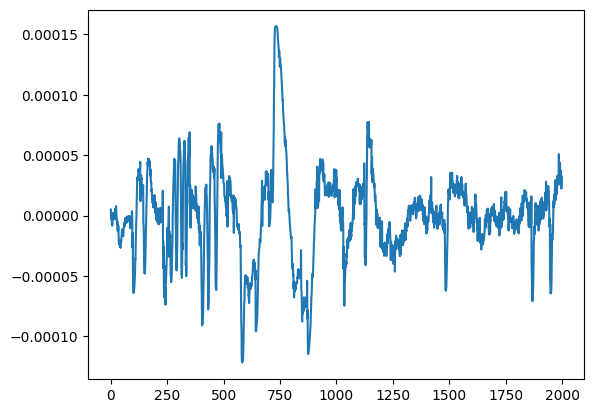

In [11]:
plt.plot(eeg_channel1[:2000]) # remember we have a sampling rate of 100Hz or 100 samples per second are taken in data
# so to get number of seconds- 2000/100 = 20 seconds of data

On the y axis of the plot obtained, we have microvoltages (diff between different electrodes Fpz minus Cz and Pz minus Oz which are bipolar montages i.e, we have two electrodes on the head of a patient and we measure the differences in voltage. Fpz is near front of head at nasion and Oz is near back of head at inion. 

Bipolar montages are EEG recording configurations in which each channel represents the voltage difference between two adjacent scalp electrodes.

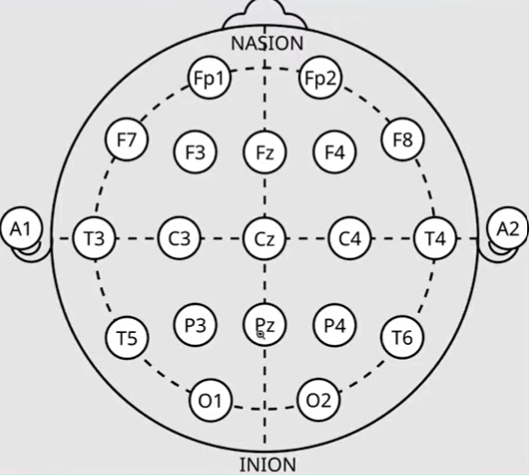

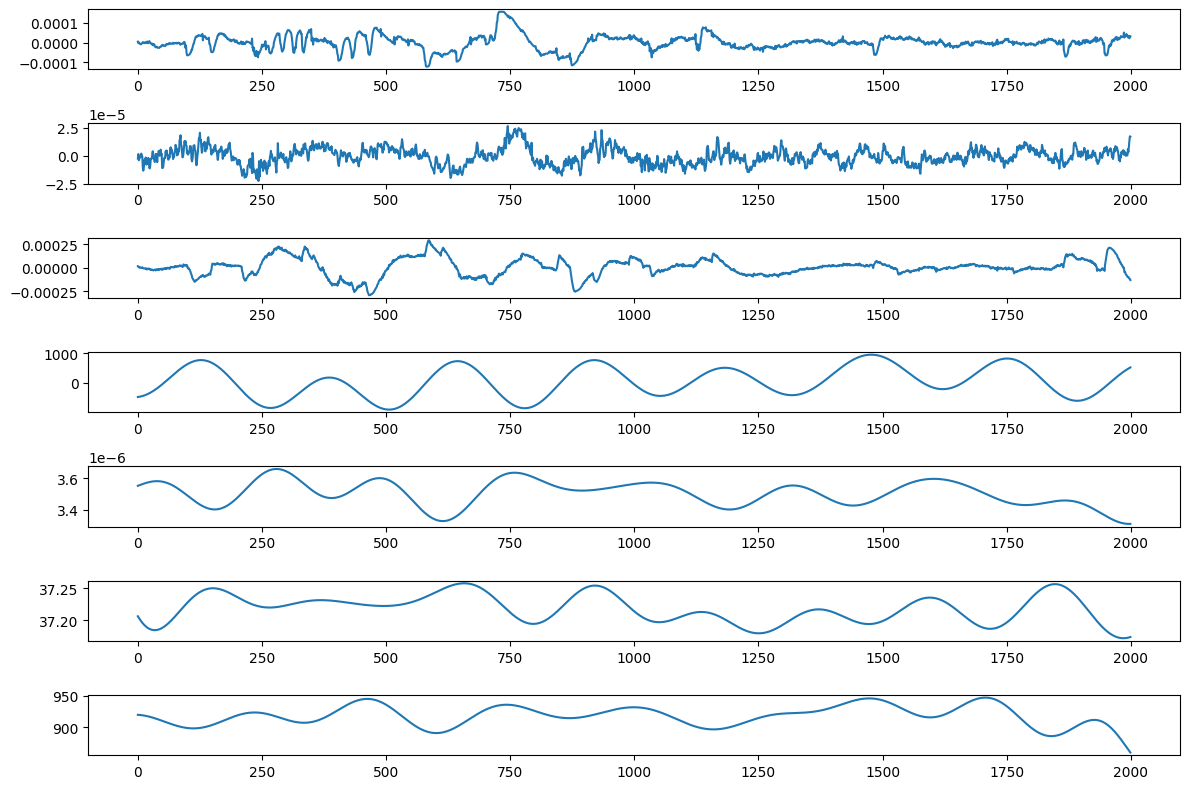

In [12]:
# plot all the data to take look at diff channels we have
fig, axs = plt.subplots(nrows = 7, ncols = 1, figsize = (12,8)) # there are 7 channels in one col

for i, ax in enumerate(axs):
    ax.plot(eeg_data[i][:2000]) # plot first 20 seconds

plt.tight_layout()

In [13]:
# Create proper visualizations with proper labelling for the two eeg channels we want
eeg_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz']

eeg_data = raw_edf.get_data(picks = eeg_channels) # only picks eeg channels

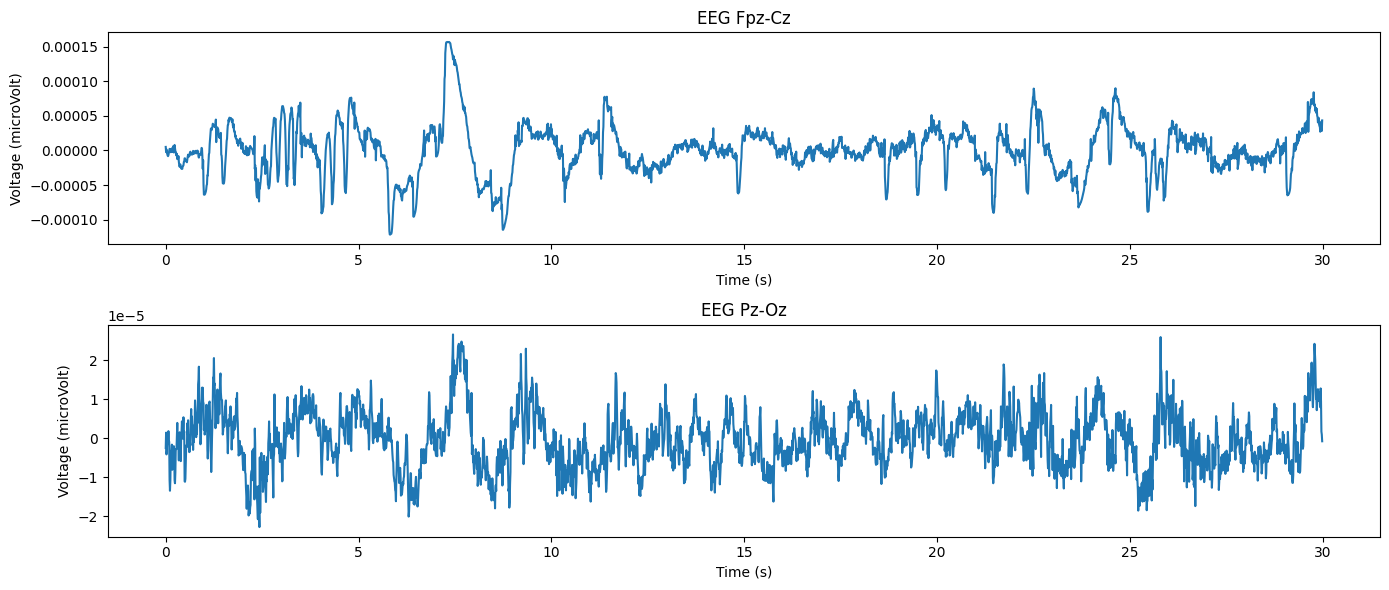

In [14]:
fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize = (14,6))

# Since we want to have proper labelling and seconds on x axis, we need to divide by sampling rate
fs = 100 # sampling frequency
N = 3000 # 30seconds of data

for i, ax in enumerate(axs):
    x = np.arange(N)/ fs # give me the values from 0 up until 3000 but divide by fs. Now every data point is 0.01 s

    ax.plot(x, eeg_data[i][:N]) # i for respective channel
    ax.set_title(eeg_channels[i]) # bipolar montages
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Voltage (microVolt)')

plt.tight_layout()

In [15]:
# Ground truth at the thing we want to predict at the labels
annotations = mne.read_annotations(hypnogram_files[0])

In [16]:
annotations


<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>

In [17]:
# 3 vals which are imp- onset (starting point of sleep stage), duration (how long a certain stage lasts), description (label of sleep stage)

annotations.onset # gives timestamp when new sleep stage starts

annotations.duration

annotations.description

array(['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3',
       'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage 3',
       'Sleep stage 4', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage 3',
       'Sleep stage 4', 'Sleep stage W', 'Sleep stage 3', 'Sleep stage 2',
       'Sleep stage 3', 'Sleep stage 4', 'Sleep stage 3', 'Sleep stage 4',
       'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 2', 'Sleep stage 3',
       'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 2',
       'Sleep stage 3', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4',
       'Sleep stage 3', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4',
       'Sleep stage 3', 'Sleep stage 4', 'Sleep stage 1', 'Sleep stage 3',
       'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 2', 'Sleep stage 3',
       'Sleep stage R', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3',
       'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 1', 'Sleep stage 2',
       'Sleep stage 3', '

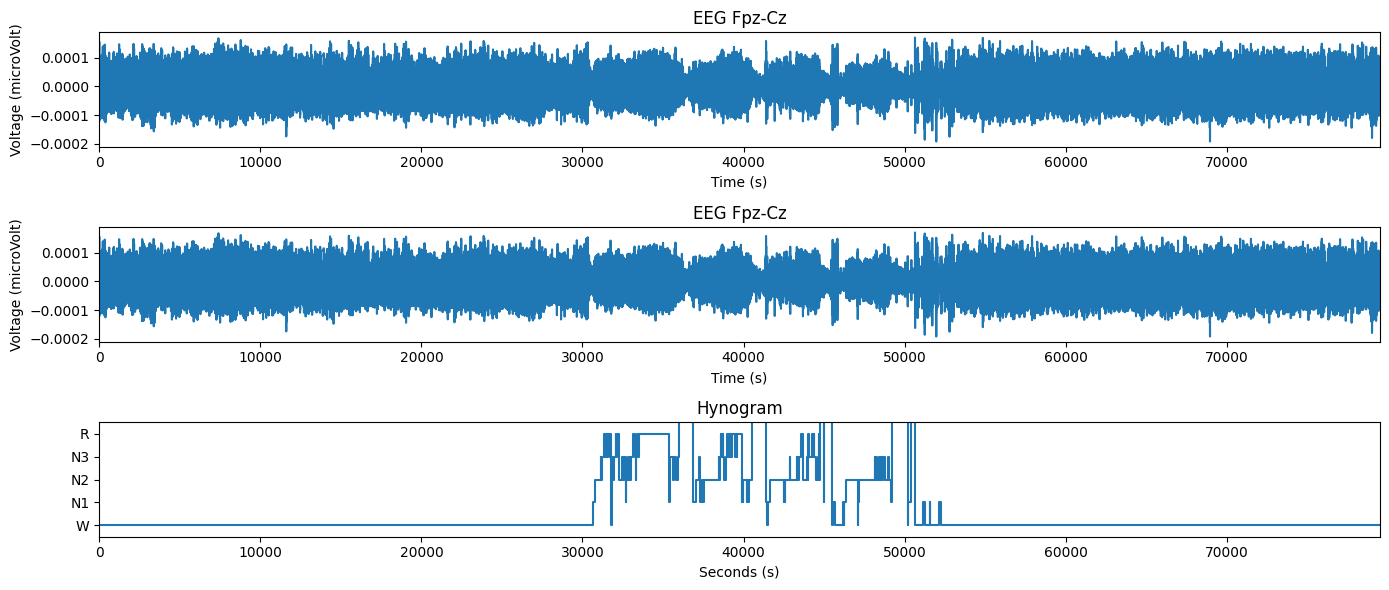

In [18]:
fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (14,6))

# Since we want to have proper labelling and seconds on x axis, we need to divide by sampling rate
fs = 100 # sampling frequency
N = 7950000

#Axis 1 - EEG
x = np.arange(N)/ fs

axs[0].plot(x, eeg_data[0][:N])
axs[0].set_title(eeg_channels[0]) # bipolar montages
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Voltage (microVolt)')

axs[0].set_xlim(0, N/fs)

#Axis 2 - EEG
x = np.arange(N)/ fs

axs[1].plot(x, eeg_data[0][:N])
axs[1].set_title(eeg_channels[0]) # bipolar montages
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Voltage (microVolt)')

axs[1].set_xlim(0, N/fs)

#Axis 3 - Hynogram
t_end = N/fs

stage_map = {'Sleep stage W': 0,'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 4, 'Sleep stage R': 5}

x, y = [], []
for o, d, s in zip(annotations.onset, annotations.duration, annotations.description):
    start, end = max(o, 0), min(o+d, t_end)
    stage = stage_map.get(s, np.nan)
    x += [start, end]
    y += [stage, stage]

axs[2].step(x, y, where = 'post')
axs[2].set_xlim(0, t_end)
axs[2].set_ylim(-0.5, 4.5)
axs[2].set_yticks([0,1,2,3,4])
axs[2].set_yticklabels(['W', 'N1', 'N2', 'N3', 'R'])
axs[2].set_xlabel('Seconds (s)')
axs[2].set_title('Hynogram')

plt.tight_layout()

### DATA PREPARATION

Two things are done here: training the model on a single channel to predict sleep stage and then use both channels to check if we get better results

In [19]:
# SINGLE CHANNEL

len(psg_files)

153

In [20]:
X_data = []
y_data = []

# how many seconds do i want to look at data to determine whether a person is sleeping or not and if sleeping then what stage they're in
window_length = 3000 # 30 seconds

for psg_file, hypnogram_file in zip(psg_files[:25], hypnogram_files[:25]): # use first 25 and for each subject load data
    raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
    eeg_channel1 = raw_edf.get_data(picks = ['EEG Fpz-Cz'])[0]

    annotations = mne.read_annotations(hypnogram_file)

    # We need a dict to map description values to numbers
    stage_map = {'Sleep stage W': 0,'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 4, 'Sleep stage R': 5}

    # Construct actual data segments
    for i, (onset, duration, description) in enumerate(zip(annotations.onset, annotations.duration, annotations.description)):
        # if description is not part of map we just continue
        if description not in stage_map:
            continue

        # Craft segments: we're going from the onset of the phase up until onset + duration i.e, end of sleep stage. Window length is step size of segment is 3000
        for segment in range(int(onset* fs), int(onset*fs + duration), window_length): # onset is in seconds so multiply by fs
            start_sample = segment # control variable
            end_sample = segment + window_length

            # Check if we are out of bounds
            if end_sample <= len(eeg_channel1):
                window = eeg_channel1[start_sample:end_sample]

                if len(window) == window_length:
                    X_data.append(window)
                    y_data.append(stage_map[description])

X = np.array(X_data)
y = np.array(y_data)

'''
In summary, we load for each subject the PSG file, the hypnogram. We load the first EEG channel then the annotations.
We create a dictionary for mapping strings to numbers, then iterate over the label time segments and we craft 30 
second windows that we add as training data w/ respective classification
'''
    

/tmp/ipykernel_25/2528829548.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
/tmp/ipykernel_25/2528829548.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
/tmp/ipykernel_25/2528829548.py:8: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
/tmp/ipykernel_25/2528829548.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
/tmp/ipykernel_25/2528829548.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  r

'\nIn summary, we load for each subject the PSG file, the hypnogram. We load the first EEG channel then the annotations.\nWe create a dictionary for mapping strings to numbers, then iterate over the label time segments and we craft 30 \nsecond windows that we add as training data w/ respective classification\n'

In [21]:
X.shape

(3760, 3000)

In [22]:
y.shape

(3760,)

In [23]:
# to show distribution of y. How many instances we have of each sleep stage
np.bincount(y)

array([ 762,  699, 1061,  714,  239,  285])

In [24]:
# Preparing data for nn: normalization and train test split

X = (X - X.mean())/ X.std()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y) 
# we stratify for y cos we want to have equal distribution of classes when it comes to split

In [25]:
# After stratification the below two will be similar
np.bincount(y_train)/ len(y_train)
np.bincount(y_test)/ len(y_test)

array([0.20212766, 0.18617021, 0.28191489, 0.19015957, 0.06382979,
       0.07579787])

In [26]:
# Getting into pytorch 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Since we're just using one channel add unsqueeze to add additional dimension
X_train = torch.FloatTensor(X_train).unsqueeze(1).to(device)
X_test = torch.FloatTensor(X_test).unsqueeze(1).to(device)
y_train = torch.LongTensor(y_train).to(device)
y_test = torch.LongTensor(y_test).to(device)

In [27]:
device

device(type='cuda')

### MODEL TRAINING: DEFINE CNN

In [28]:
model = nn.Sequential(
    # Define one d convolutional layers since we're working with time series not images
    nn.Conv1d(1,32,kernel_size = 50, stride = 6), # 1 input channel, 32 filters or kernels i.e., 32 output channels, step size is 6
    nn.ReLU(), # ReLU function to break linearity
    nn.MaxPool1d(8), # kernel size 8
    nn.Conv1d(32, 64, kernel_size = 8),
    nn.ReLU(),
    nn.MaxPool1d(8),
    nn.Flatten(),
    nn.Linear(64*6, 128), # fully connected layer (input, output neurons)
    nn.ReLU(),
    nn.Dropout(0.5), # for regularization with probability of 0.5
    nn.Linear(128, 6) # fcl layer which take 128 signals and outputs 6 - waking state, rem state, 4 sleep stages 
).to(device)

# Define loos function and criterion
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) # optimize params

In [29]:
epochs = 10
batch_size = 64

for epoch in range(epochs):
    model.train()

    total_loss = 0

    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i+batch_size].to(device)
        batch_y = y_train[i:i+batch_size].to(device)

        optimizer.zero_grad()

        # Make prediction with current weights and biases- evaluate losses then backpropagate it and take a step with the optimizer
        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(X_train):.4f}')
 

Epoch 1/10, Loss: 0.0253
Epoch 2/10, Loss: 0.0190
Epoch 3/10, Loss: 0.0165
Epoch 4/10, Loss: 0.0155
Epoch 5/10, Loss: 0.0147
Epoch 6/10, Loss: 0.0141
Epoch 7/10, Loss: 0.0135
Epoch 8/10, Loss: 0.0133
Epoch 9/10, Loss: 0.0132
Epoch 10/10, Loss: 0.0127


In [30]:
# Evaluate model on unseen data
model.eval()

with torch.no_grad():
    predictions = model(X_test)
    predicted_classes = torch.argmax(predictions, dim = 1).cpu().numpy()

accuracy = accuracy_score(y_test.cpu().numpy(), predicted_classes)

In [31]:
accuracy

0.6409574468085106

In [32]:
confusion_matrix(y_test.cpu().numpy(), predicted_classes)

array([[111,  31,   6,   4,   0,   0],
       [ 12,  69,  57,   2,   0,   0],
       [  2,   6, 161,  43,   0,   0],
       [  1,   0,  18, 117,   7,   0],
       [  0,   0,   0,  24,  24,   0],
       [  0,   2,  55,   0,   0,   0]])

###  Data preparation (2 channels)

In [33]:
X_data = []
y_data = []

# how many seconds do i want to look at data to determine whether a person is sleeping or not and if sleeping then what stage they're in
window_length = 3000 # 30 seconds

for psg_file, hynogram_file in zip(psg_files[:25], hypnogram_files[:25]): # use first 25 and for each subject load data
    raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
    eeg_channel1 = raw_edf.get_data(picks = ['EEG Fpz-Cz'])[0]
    eeg_channel2 = raw_edf.get_data(picks = ['EEG Pz-Oz'])[0]

    annotations = mne.read_annotations(hypnogram_file)

    # We need a dict to map description values to numbers
    stage_map = {'Sleep stage W': 0,'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 4, 'Sleep stage R': 5}

    # Construct actual data segments
    for i, (onset, duration, description) in enumerate(zip(annotations.onset, annotations.duration, annotations.description)):
        # if description is not part of map we just continue
        if description not in stage_map:
            continue

        # Craft segments: we're going from the onset of the phase up until onset + duration i.e, end of sleep stage. Window length is step size of segment is 3000
        for segment in range(int(onset* fs), int(onset*fs + duration), window_length): # onset is in seconds so multiply by fs
            start_sample = segment # control variable
            end_sample = segment + window_length

            # Check if we are out of bounds
            if end_sample <= len(eeg_channel1):
                window1 = eeg_channel1[start_sample:end_sample]
                window2 = eeg_channel2[start_sample:end_sample]

                if len(window1) == window_length:
                    X_data.append(np.stack([window1, window2], axis = 0))
                    y_data.append(stage_map[description])

X = np.array(X_data)
y = np.array(y_data)

'''
In summary, we load for each subject the PSG file, the hypnogram. We load the first EEG channel then the annotations.
We create a dictionary for mapping strings to numbers, then iterate over the label time segments and we craft 30 
second windows that we add as training data w/ respective classification
'''
    

/tmp/ipykernel_25/2618280697.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
/tmp/ipykernel_25/2618280697.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
/tmp/ipykernel_25/2618280697.py:8: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
/tmp/ipykernel_25/2618280697.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(psg_file, preload = True, verbose = False)
/tmp/ipykernel_25/2618280697.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  r

'\nIn summary, we load for each subject the PSG file, the hypnogram. We load the first EEG channel then the annotations.\nWe create a dictionary for mapping strings to numbers, then iterate over the label time segments and we craft 30 \nsecond windows that we add as training data w/ respective classification\n'

In [34]:
X.shape

(3575, 2, 3000)

In [35]:
y.shape

(3575,)

In [36]:
# Preparing data for nn: normalization and train test split

X = (X - X.mean())/ X.std()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y) 
# we stratify for y cos we want to have equal distribution of classes when it comes to split

In [37]:
# Getting into pytorch 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Since we're using 2 channels no unsqueeze needed
X_train = torch.FloatTensor(X_train).to(device) 
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.LongTensor(y_train).to(device)
y_test = torch.LongTensor(y_test).to(device)

In [38]:
model = nn.Sequential(
    # Define one d convolutional layers since we're working with time series not images
    nn.Conv1d(2,32,kernel_size = 50, stride = 6),
    nn.ReLU(),
    nn.MaxPool1d(8),
    nn.Conv1d(32, 64, kernel_size = 8),
    nn.ReLU(),
    nn.MaxPool1d(8),
    nn.Flatten(),
    nn.Linear(64*6, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 6)    
).to(device)

# Define loos function and criterion
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [39]:
epochs = 10
batch_size = 64

for epoch in range(epochs):
    model.train()

    total_loss = 0

    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i+batch_size].to(device)
        batch_y = y_train[i:i+batch_size].to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(X_train):.4f}')
 

Epoch 1/10, Loss: 0.0264
Epoch 2/10, Loss: 0.0258
Epoch 3/10, Loss: 0.0251
Epoch 4/10, Loss: 0.0247
Epoch 5/10, Loss: 0.0245
Epoch 6/10, Loss: 0.0243
Epoch 7/10, Loss: 0.0240
Epoch 8/10, Loss: 0.0240
Epoch 9/10, Loss: 0.0238
Epoch 10/10, Loss: 0.0235


In [40]:
# Evaluate model on unseen data
model.eval()

with torch.no_grad():
    predictions = model(X_test)
    predicted_classes = torch.argmax(predictions, dim = 1).cpu().numpy()

accuracy = accuracy_score(y_test.cpu().numpy(), predicted_classes)

In [41]:
accuracy

0.36363636363636365

In [42]:
confusion_matrix(y_test.cpu().numpy(), predicted_classes)

array([[ 97,   3,  75,   0,   0,   0],
       [ 46,   1, 117,   1,   0,   0],
       [ 28,   1, 160,   1,   0,   0],
       [  5,   0,  93,   2,   0,   0],
       [  4,   1,  40,   0,   0,   0],
       [ 13,   2,  24,   1,   0,   0]])